In [7]:

import numpy as np
import pandas as pd

np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

In [8]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


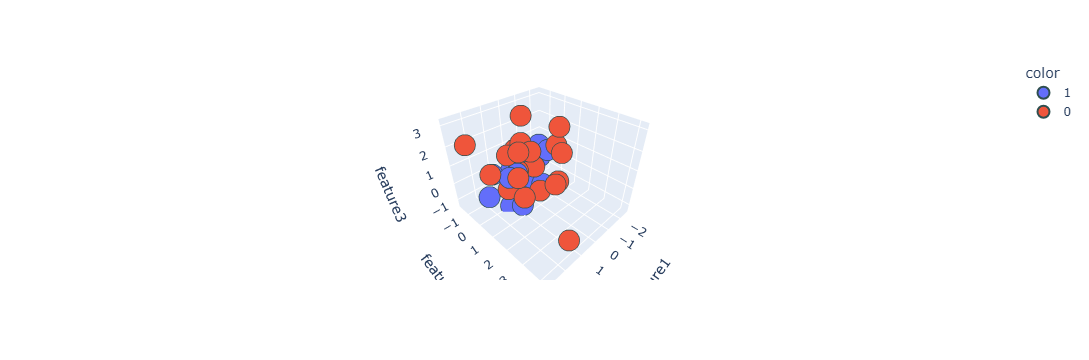

In [9]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [10]:

# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [11]:

# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [12]:

# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [13]:

eigen_values
     

array([1.3536065 , 0.94557084, 0.77774573])

In [14]:

eigen_vectors
     

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

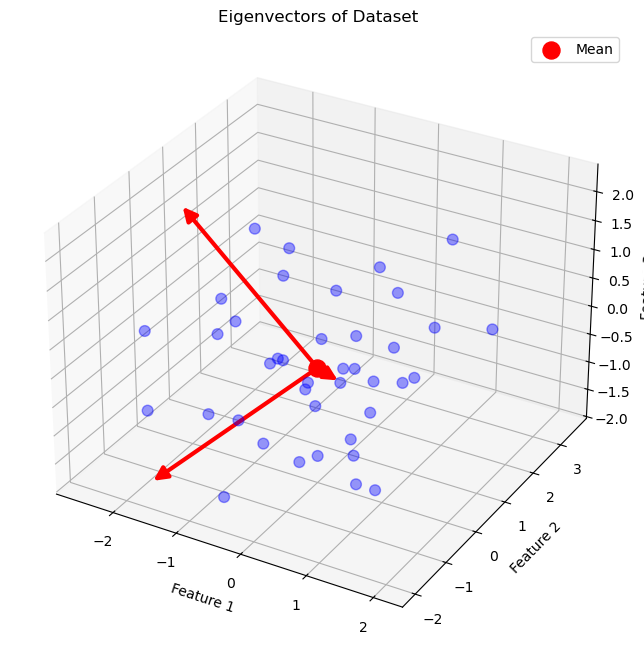

In [16]:
# ===========================
# Imports
# ===========================

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

# ===========================
# Calculate Eigenvectors
# ===========================

X = df[['feature1', 'feature2', 'feature3']]

# Mean of data
mean = X.mean().values

# Covariance Matrix
cov_mat = np.cov(X.T)

# Eigen Values & Eigen Vectors
eigen_values, eigen_vectors = np.linalg.eig(cov_mat)

# ===========================
# Updated Arrow3D Class
# ===========================

class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.get_proj()
        )

        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))

        return np.min(zs)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.get_proj()
        )

        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))

        super().draw(renderer)

# ===========================
# Plot
# ===========================

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Plot Data Points
ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    color='blue',
    alpha=0.4,
    s=60
)

# Plot Mean Point
ax.scatter(
    mean[0],
    mean[1],
    mean[2],
    color='red',
    s=150,
    label='Mean'
)

# Draw Eigenvectors
scale = 3

for v in eigen_vectors.T:

    arrow = Arrow3D(
        [mean[0], mean[0] + scale*v[0]],
        [mean[1], mean[1] + scale*v[1]],
        [mean[2], mean[2] + scale*v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="red"
    )

    ax.add_artist(arrow)

# Labels
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")

plt.title("Eigenvectors of Dataset")
plt.legend()

plt.show()

In [17]:

pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [18]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


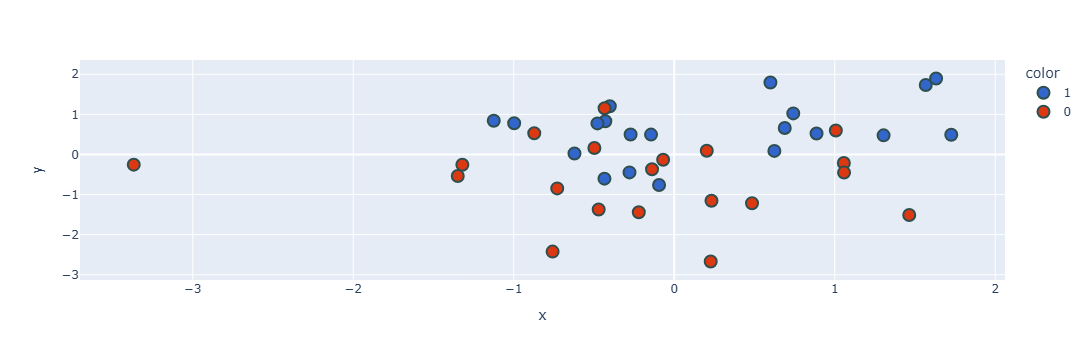

In [19]:

new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()